In [1]:
### Import libraries ###
%matplotlib inline
import re
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

base_dir = os.path.abspath(os.path.join(os.getcwd(), '../'))
sys.path.append(base_dir)
from scripts import statsplot as lsp

In [4]:
dc2 = pd.read_csv(os.path.join(base_dir, 'simulation_catalogs/DC2/dp02_dc2_62.csv'))
dc2 = dc2.dropna()
dc2

,mt_id_truth_type,mt_match_objectId,ts_ra,ts_dec,ts_truth_type,ts_is_pointsource,ts_redshift,obj_coord_ra,obj_coord_dec,obj_refExtendedness,...,rmag,imag,zmag,ymag,umag_err,gmag_err,rmag_err,imag_err,zmag_err,ymag_err
2,31411981094_2,1651413688361421449,61.944366,-36.507034,2,1,0.000000,61.944356,-36.507118,1.0,...,25.961597,25.452401,25.984570,24.876525,0.444678,0.249135,0.154769,0.190892,0.823338,0.522780
4,31411982728_2,1651413688361451863,61.944980,-36.517584,2,1,0.000000,61.945022,-36.517598,1.0,...,25.458261,24.611190,24.224103,24.008730,2.442508,0.108411,0.091213,0.082115,0.145041,0.210407
5,7943780948_1,1651413688361451723,61.826612,-36.523895,1,0,1.583830,61.826611,-36.523902,0.0,...,27.333583,26.705990,26.398789,25.543027,1.065680,0.124979,0.343457,0.361728,0.780762,0.740926
6,7943693455_1,1651413688361451008,61.834454,-36.527883,1,0,1.574190,61.834410,-36.527846,1.0,...,27.106075,27.495085,25.899755,25.413648,1.267743,0.159137,0.302248,0.793405,0.519312,0.666858
7,7942562735_1,1651413688361450766,61.844052,-36.529150,1,0,1.406630,61.844022,-36.529129,1.0,...,25.974539,25.917630,26.159017,26.046129,3.300565,0.140450,0.139756,0.254179,0.835466,1.465326
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
331226,7943945656_1,1651220174314963390,62.142014,-37.157586,1,0,1.619990,62.142023,-37.157590,1.0,...,24.364884,24.034992,23.549956,23.572616,0.134820,0.029127,0.030680,0.039934,0.073955,0.152567
331227,7939904273_1,1651220174314979605,62.196071,-37.188057,1,0,0.991601,62.196074,-37.188082,1.0,...,26.648801,26.259573,25.662613,27.301982,0.424547,0.237019,0.225189,0.257267,0.448459,4.267782
331228,7941557652_1,1651220174314968068,62.087862,-37.112980,1,0,1.293110,62.087878,-37.113049,1.0,...,25.461772,25.860497,25.663130,24.291075,0.199773,0.082895,0.077138,0.208592,0.530722,0.267100
331232,7952939272_1,1567956357766723215,62.007438,-37.312334,1,0,2.321760,62.007407,-37.312425,1.0,...,26.769156,26.612160,25.948089,25.386089,1.705743,0.171166,0.273550,0.478872,0.680196,0.885777


/tmp/ipykernel_12636/1908715700.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dc2_stars = dc2_stars[snr_mask]
/tmp/ipykernel_12636/1908715700.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dc2_gal = dc2_gal[snr_mask]


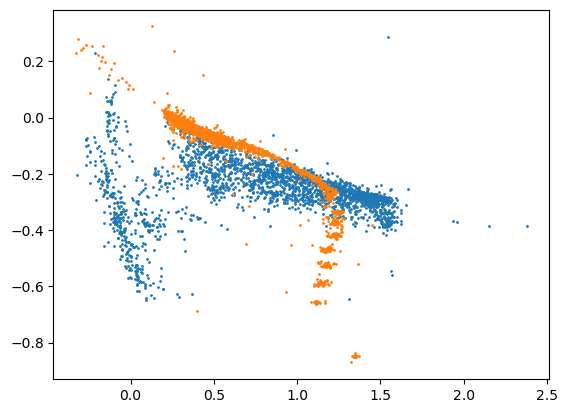

In [5]:
snr_mask = dc2['gmag']/dc2['gmag_err'] > 5000
dc2_stars = dc2[dc2['ts_truth_type'] == 2]
dc2_stars = dc2_stars[snr_mask]
dc2_gal = dc2[dc2['ts_truth_type'] == 1]
dc2_gal = dc2_gal[snr_mask]


plt.figure()

plt.scatter(dc2_gal['gmag']-dc2_gal['rmag'], dc2_gal['zmag'] - dc2_gal['imag'], s=1)
plt.scatter(dc2_stars['gmag']-dc2_stars['rmag'], dc2_stars['zmag'] - dc2_stars['imag'], s=1)

plt.show()